<a href="https://colab.research.google.com/github/2004-weerakkody/2004-weerakkody/blob/main/AIml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported ✔")

Libraries imported ✔


In [2]:
iris = load_iris()

P = iris.data[:, 2:4]          # petal length & width ONLY

print("shape of P:", P.shape)          # 150 flowers, 2 features
print("feature names:", iris.feature_names[2:4])
print("\nfirst 5 rows:\n", P[:5])

shape of P: (150, 2)
feature names: ['petal length (cm)', 'petal width (cm)']

first 5 rows:
 [[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]


In [3]:
scaler = StandardScaler().fit(P)
Ps = scaler.transform(P)       # scale — distance calculation sadaha

print("mean of each scaled feature :", Ps.mean(axis=0).round(3))   # ~ 0
print("std  of each scaled feature :", Ps.std(axis=0).round(3))    # ~ 1
print("\nfirst 5 scaled rows:\n", Ps[:5].round(2))

mean of each scaled feature : [-0. -0.]
std  of each scaled feature : [1. 1.]

first 5 scaled rows:
 [[-1.34 -1.32]
 [-1.34 -1.32]
 [-1.4  -1.32]
 [-1.28 -1.32]
 [-1.34 -1.32]]


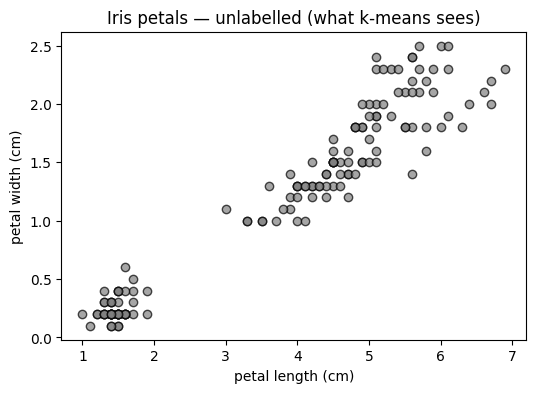

In [4]:
plt.figure(figsize=(6, 4))
plt.scatter(P[:, 0], P[:, 1], c="grey", edgecolor="k", alpha=0.7)
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Iris petals — unlabelled (what k-means sees)")
plt.show()

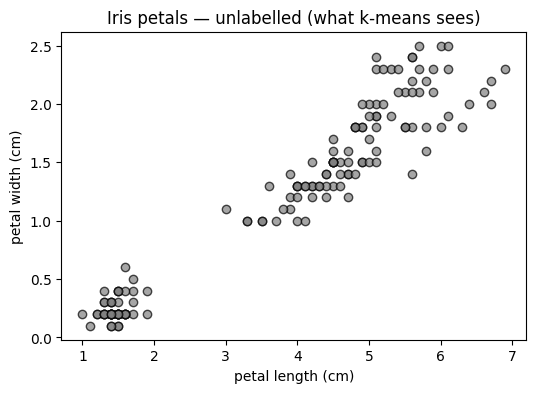

In [5]:
plt.figure(figsize=(6, 4))
plt.scatter(P[:, 0], P[:, 1], c="grey", edgecolor="k", alpha=0.7)
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("Iris petals — unlabelled (what k-means sees)")
plt.show()

In [6]:
km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Ps)

print("model fitted ✔")
print("number of clusters:", km.n_clusters)

model fitted ✔
number of clusters: 3


In [7]:
print("cluster of the first 20 flowers:")
print(km.labels_[:20])

print("\nthe 3 cluster centres (scaled units):")
print(km.cluster_centers_.round(2))

print("\nhow many flowers per cluster:")
vals, counts = np.unique(km.labels_, return_counts=True)
for v, c in zip(vals, counts):
    print(f"  cluster {v}: {c} flowers")

cluster of the first 20 flowers:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

the 3 cluster centres (scaled units):
[[ 0.31  0.17]
 [-1.3  -1.25]
 [ 1.03  1.13]]

how many flowers per cluster:
  cluster 0: 52 flowers
  cluster 1: 50 flowers
  cluster 2: 48 flowers


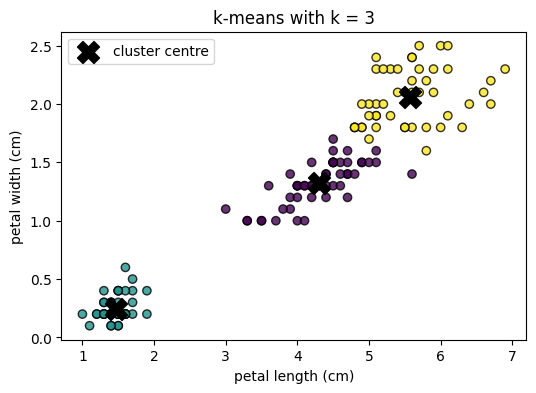

cluster centres in original units (petal length, petal width):
[[4.3  1.32]
 [1.46 0.25]
 [5.57 2.06]]


In [8]:
centres_original = scaler.inverse_transform(km.cluster_centers_)

plt.figure(figsize=(6, 4))
plt.scatter(P[:, 0], P[:, 1], c=km.labels_, cmap="viridis", edgecolor="k", alpha=0.8)
plt.scatter(centres_original[:, 0], centres_original[:, 1],
            s=250, marker="X", c="black", label="cluster centre")

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("k-means with k = 3")
plt.legend()
plt.show()

print("cluster centres in original units (petal length, petal width):")
print(centres_original.round(2))

In [9]:
inertias = []

for k in range(1, 7):
    model = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Ps)
    inertias.append(model.inertia_)
    print(f"k = {k}  ->  inertia = {model.inertia_:.1f}")

k = 1  ->  inertia = 300.0
k = 2  ->  inertia = 54.2
k = 3  ->  inertia = 18.0
k = 4  ->  inertia = 12.3
k = 5  ->  inertia = 9.2
k = 6  ->  inertia = 7.2


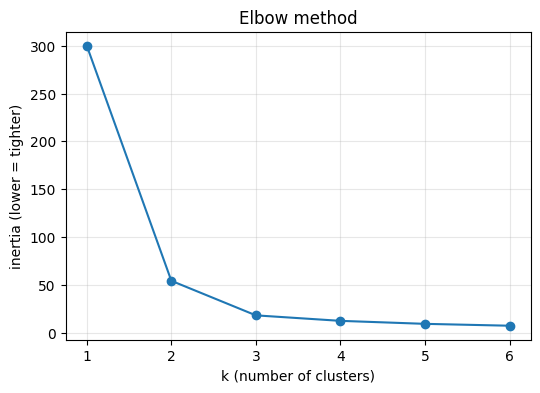

[300.0, 54.2, 18.0, 12.3, 9.2, 7.2]


In [10]:
plt.figure(figsize=(6, 4))
plt.plot(range(1, 7), inertias, "o-")
plt.xlabel("k (number of clusters)")
plt.ylabel("inertia (lower = tighter)")
plt.title("Elbow method")
plt.xticks(range(1, 7))
plt.grid(alpha=0.3)
plt.show()

print([round(i, 1) for i in inertias])

In [11]:
for k in range(2, 7):
    drop = inertias[k - 2] - inertias[k - 1]
    pct = 100 * drop / inertias[k - 2]
    print(f"k {k-1} -> {k}:  inertia drops by {drop:6.1f}  ({pct:5.1f}%)")

k 1 -> 2:  inertia drops by  245.8  ( 81.9%)
k 2 -> 3:  inertia drops by   36.1  ( 66.7%)
k 3 -> 4:  inertia drops by    5.7  ( 31.9%)
k 4 -> 5:  inertia drops by    3.1  ( 25.5%)
k 5 -> 6:  inertia drops by    2.0  ( 21.5%)


In [12]:
import pandas as pd

y = iris.target

print("species codes :", np.unique(y))
print("species names :", list(iris.target_names))
print("\nfirst 20 true species:", y[:20])

species codes : [0 1 2]
species names : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

first 20 true species: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
ct = pd.crosstab(km.labels_, y)
ct.index.name = "cluster"
ct.columns = iris.target_names

print(ct)

         setosa  versicolor  virginica
cluster                               
0             0          48          4
1            50           0          0
2             0           2         46


In [14]:
correct = 0

for c in range(3):
    members = y[km.labels_ == c]
    counts = np.bincount(members, minlength=3)
    best = counts.argmax()
    correct += counts[best]
    print(f"cluster {c}: {len(members):3d} flowers, mostly '{iris.target_names[best]}' ({counts[best]}/{len(members)})")

accuracy = correct / len(y)
print(f"\nOverall match with the true species: {correct}/{len(y)} = {accuracy:.1%}")

cluster 0:  52 flowers, mostly 'versicolor' (48/52)
cluster 1:  50 flowers, mostly 'setosa' (50/50)
cluster 2:  48 flowers, mostly 'virginica' (46/48)

Overall match with the true species: 144/150 = 96.0%


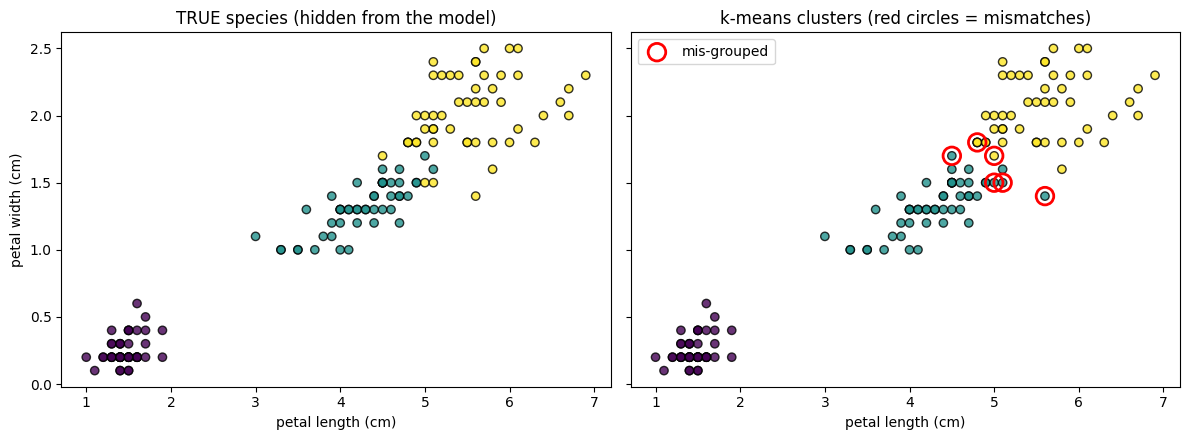

number of mis-grouped flowers: 6


In [15]:
cluster_to_species = {}
for c in range(3):
    cluster_to_species[c] = np.bincount(y[km.labels_ == c], minlength=3).argmax()

pred_species = np.array([cluster_to_species[c] for c in km.labels_])
mistakes = pred_species != y

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)

ax[0].scatter(P[:, 0], P[:, 1], c=y, cmap="viridis", edgecolor="k", alpha=0.8)
ax[0].set_title("TRUE species (hidden from the model)")

ax[1].scatter(P[:, 0], P[:, 1], c=pred_species, cmap="viridis", edgecolor="k", alpha=0.8)
ax[1].scatter(P[mistakes, 0], P[mistakes, 1], s=160, facecolors="none",
              edgecolors="red", linewidths=2, label="mis-grouped")
ax[1].set_title("k-means clusters (red circles = mismatches)")
ax[1].legend()

for a in ax:
    a.set_xlabel("petal length (cm)")
ax[0].set_ylabel("petal width (cm)")
plt.tight_layout()
plt.show()

print("number of mis-grouped flowers:", mistakes.sum())